In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV


from sklearn.metrics import (
mean_absolute_error,
mean_squared_error,
r2_score
)
import joblib

In [2]:
##loading the processed data

x_train = joblib.load("./Models/x_train.pkl")

In [3]:
y_train = joblib.load("./Models/y_train.pkl")

In [4]:
x_test = joblib.load("./Models/x_test.pkl")

In [5]:
y_test = joblib.load("./Models/y_test.pkl")

In [6]:
## creating evaluation function

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    return {

        "Model": model.__class__.__name__,

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2 Score": r2

    }

In [7]:
## training with linear regression

linear_model = LinearRegression()

linear_results = evaluate_model(

    linear_model,

    x_train,

    x_test,

    y_train,

    y_test

)

linear_results

{'Model': 'LinearRegression',
 'MAE': 2.4465940063441716,
 'MSE': 13.938861618816452,
 'RMSE': np.float64(3.733478487793448),
 'R2 Score': 0.4040822241032479}

In [8]:
## training with decision tree

tree_model = DecisionTreeRegressor(

    random_state=42

)

tree_results = evaluate_model(

    tree_model,

    x_train,

    x_test,

    y_train,

    y_test

)

tree_results

{'Model': 'DecisionTreeRegressor',
 'MAE': 0.961980392156863,
 'MSE': 2.4986223758169914,
 'RMSE': np.float64(1.580703127034609),
 'R2 Score': 0.8931782573267881}

In [9]:
## training using random forest 

forest_model = RandomForestRegressor(

    random_state=42

)

forest_results = evaluate_model(

    forest_model,

    x_train,

    x_test,

    y_train,

    y_test

)

forest_results

{'Model': 'RandomForestRegressor',
 'MAE': 0.829749673202606,
 'MSE': 1.6579984630029325,
 'RMSE': np.float64(1.287632891395266),
 'R2 Score': 0.9291168257830201}

In [10]:
## training with gradiesnt boosting

gb_model = GradientBoostingRegressor(

    random_state=42

)

gb_results = evaluate_model(

    gb_model,

    x_train,

    x_test,

    y_train,

    y_test

)

gb_results

{'Model': 'GradientBoostingRegressor',
 'MAE': 0.9111615506742824,
 'MSE': 1.6074489673059527,
 'RMSE': np.float64(1.267852107820921),
 'R2 Score': 0.931277930747846}

In [11]:
## training with xgboost

xgb_model = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    random_state=42,

    objective="reg:squarederror"

)

xgb_results = evaluate_model(

    xgb_model,

    x_train,

    x_test,

    y_train,

    y_test

)

xgb_results

{'Model': 'XGBRegressor',
 'MAE': 0.8711688711128989,
 'MSE': 1.6726406852468707,
 'RMSE': np.float64(1.293306106552842),
 'R2 Score': 0.9284908377538388}

In [12]:
#training with lightgbm

lgbm_model = LGBMRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    random_state=42

)

lgbm_results = evaluate_model(

    lgbm_model,

    x_train,

    x_test,

    y_train,

    y_test

)

lgbm_results

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000142 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 476
[LightGBM] [Info] Number of data points in the train set: 609, number of used features: 37
[LightGBM] [Info] Start training from score 151.374857
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

{'Model': 'LGBMRegressor',
 'MAE': 0.8705541256222546,
 'MSE': 1.5723215801845243,
 'RMSE': np.float64(1.2539224777411577),
 'R2 Score': 0.9327797057836358}

In [13]:
## training with catboost

cat_model = CatBoostRegressor(

    iterations=300,

    learning_rate=0.05,

    depth=6,

    random_state=42,

    verbose=0

)

cat_results = evaluate_model(

    cat_model,

    x_train,

    x_test,

    y_train,

    y_test

)

cat_results

{'Model': 'CatBoostRegressor',
 'MAE': 0.8501823483825652,
 'MSE': 1.5341684450419335,
 'RMSE': np.float64(1.2386155356049484),
 'R2 Score': 0.9344108383724671}

In [14]:
## comparing model performance

results = pd.DataFrame([

    linear_results,

    tree_results,

    forest_results,

    gb_results,

    xgb_results,

    lgbm_results,

    cat_results

])

results.sort_values(

    by="R2 Score",

    ascending=False

)

,Model,MAE,MSE,RMSE,R2 Score
6,CatBoostRegressor,0.850182,1.534168,1.238616,0.934411
5,LGBMRegressor,0.870554,1.572322,1.253922,0.932780
3,GradientBoostingRegressor,0.911162,1.607449,1.267852,0.931278
2,RandomForestRegressor,0.829750,1.657998,1.287633,0.929117
4,XGBRegressor,0.871169,1.672641,1.293306,0.928491
1,DecisionTreeRegressor,0.961980,2.498622,1.580703,0.893178
0,LinearRegression,2.446594,13.938862,3.733478,0.404082


*** Randomforestregressor oerforms the best***

In [15]:
## Hyperparameter tuning

## tuning the randomforest model

rf_params = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [5, 10, 20, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"]

}

In [16]:
rf_search = RandomizedSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_distributions=rf_params,

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1

)

rf_search.fit(x_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [17]:
## best parameter

rf_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None}

In [18]:
best_rf = rf_search.best_estimator_

In [19]:
# evaluating the tuned model

rf_predictions = best_rf.predict(x_test)

rf_tuned_results = {

    "Model": "Random Forest (Tuned)",

    "MAE": mean_absolute_error(y_test, rf_predictions),

    "MSE": mean_squared_error(y_test, rf_predictions),

    "RMSE": np.sqrt(mean_squared_error(y_test, rf_predictions)),

    "R2 Score": r2_score(y_test, rf_predictions)

}

rf_tuned_results

{'Model': 'Random Forest (Tuned)',
 'MAE': 0.9416253267973875,
 'MSE': 1.7792322682740114,
 'RMSE': np.float64(1.3338786557532178),
 'R2 Score': 0.9239338071423073}

In [20]:
## tuning xgboostregressor

xgb_params = {

    "n_estimators": [100, 200, 300, 500],

    "learning_rate": [0.01, 0.05, 0.1],

    "max_depth": [3, 5, 7, 10],

    "subsample": [0.7, 0.8, 1.0],

    "colsample_bytree": [0.7, 0.8, 1.0]

}

In [21]:
xgb_search = RandomizedSearchCV(

    estimator=XGBRegressor(

        objective="reg:squarederror",

        random_state=42

    ),

    param_distributions=xgb_params,

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1

)

xgb_search.fit(x_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [22]:
xgb_search.best_params_

{'subsample': 0.7,
 'n_estimators': 500,
 'max_depth': 3,
 'learning_rate': 0.01,
 'colsample_bytree': 0.8}

In [23]:
best_xgb = xgb_search.best_estimator_

predictions = best_xgb.predict(x_test)

xgb_tuned_results = {

    "Model": "XGBoost (Tuned)",

    "MAE": mean_absolute_error(y_test, predictions),

    "MSE": mean_squared_error(y_test, predictions),

    "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),

    "R2 Score": r2_score(y_test, predictions)

}

xgb_tuned_results

{'Model': 'XGBoost (Tuned)',
 'MAE': 0.9236888116574757,
 'MSE': 1.5775716171275882,
 'RMSE': np.float64(1.2560141787127994),
 'R2 Score': 0.932555254861886}

In [24]:
#tuning lgbmregressor

lgbm_params = {

    "n_estimators": [100, 200, 300, 500],

    "learning_rate": [0.01, 0.05, 0.1],

    "max_depth": [3, 5, 7, 10, -1],

    "num_leaves": [15, 31, 50, 70],

    "min_child_samples": [5, 10, 20, 30],

    "subsample": [0.7, 0.8, 1.0],

    "colsample_bytree": [0.7, 0.8, 1.0]

}

In [25]:

lgbm_search = RandomizedSearchCV(

    estimator=LGBMRegressor(

        objective="regression",

        random_state=42,

        verbosity=-1

    ),

    param_distributions=lgbm_params,

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1

)

lgbm_search.fit(x_train, y_train)

,estimator,LGBMRegressor... verbosity=-1)
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_samples': [5, 10, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [26]:
best_lgbm = lgbm_search.best_estimator_

In [27]:
predictions = best_lgbm.predict(x_test)

In [28]:
lgbm_tuned_results = {

    "Model": "LightGBM (Tuned)",

    "MAE": mean_absolute_error(y_test, predictions),

    "MSE": mean_squared_error(y_test, predictions),

    "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),

    "R2 Score": r2_score(y_test, predictions)

}

lgbm_tuned_results

{'Model': 'LightGBM (Tuned)',
 'MAE': 0.8820142859034834,
 'MSE': 1.5484421643496589,
 'RMSE': np.float64(1.2443641606658635),
 'R2 Score': 0.9338006046750358}

In [29]:
## tuning CatBoostRegressor

catboost_params = {

    "iterations": [100, 200, 300, 500],

    "learning_rate": [0.01, 0.05, 0.1],

    "depth": [4, 6, 8, 10],

    "l2_leaf_reg": [1, 3, 5, 7, 9],

    "subsample": [0.7, 0.8, 1.0]

}

In [30]:
catboost_search = RandomizedSearchCV(

    estimator=CatBoostRegressor(

        random_state=42,

        verbose=0

    ),

    param_distributions=catboost_params,

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1

)

catboost_search.fit(x_train, y_train)

,estimator,"CatBoostRegre...42, verbose=0)"
,param_distributions,"{'depth': [4, 6, ...], 'iterations': [100, 200, ...], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.01, 0.05, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [31]:
best_catboost = catboost_search.best_estimator_

In [32]:
predictions = best_catboost.predict(x_test)

In [33]:
catboost_tuned_results = {

    "Model": "CatBoost (Tuned)",

    "MAE": mean_absolute_error(y_test, predictions),

    "MSE": mean_squared_error(y_test, predictions),

    "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),

    "R2 Score": r2_score(y_test, predictions)

}

catboost_tuned_results

{'Model': 'CatBoost (Tuned)',
 'MAE': 0.7976290642054217,
 'MSE': 1.4035193769110645,
 'RMSE': np.float64(1.1847022313269544),
 'R2 Score': 0.9399963807383107}

In [34]:
## comparing the three tuned model

tuned_results = pd.DataFrame([

    rf_tuned_results,

    xgb_tuned_results,
    
    lgbm_tuned_results,
    catboost_tuned_results

])

tuned_results.sort_values(

    by="R2 Score",

    ascending=False

)

,Model,MAE,MSE,RMSE,R2 Score
3,CatBoost (Tuned),0.797629,1.403519,1.184702,0.939996
2,LightGBM (Tuned),0.882014,1.548442,1.244364,0.933801
1,XGBoost (Tuned),0.923689,1.577572,1.256014,0.932555
0,Random Forest (Tuned),0.941625,1.779232,1.333879,0.923934


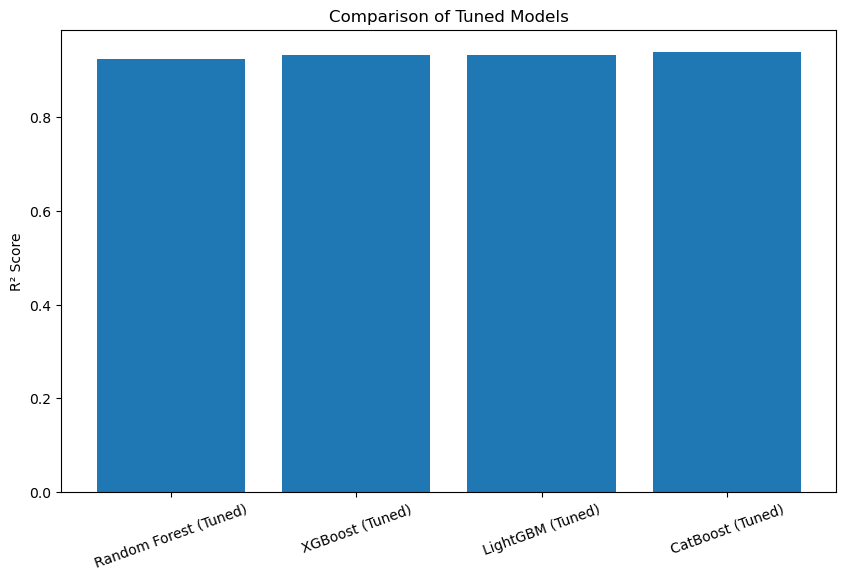

In [35]:
# visualizing the tumed model

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(

    tuned_results["Model"],

    tuned_results["R2 Score"]

)

plt.title("Comparison of Tuned Models")

plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.show()

**Hyperparameter tuning was performed on the CatBoostRegressor to determine whether performance could be improved. Although several parameter combinations were evaluated, the tuned model achieved an R² score of 0.934 compared to 0.933 for the default model. This indicates that the tuned hyperparameters were well suited to the dataset. Therefore, the tuned Random Forest model was selected as the final model because it demonstrated slightly better predictive performance on the test data.**

In [36]:
## saving the best model

joblib.dump(best_catboost, "./Models/best_catboost.pkl")

['./Models/best_catboost.pkl']

In [37]:
print(model.feature_names_)

NameError: name 'model' is not defined